# Functions to parse and clean data

### Imports

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parse data

In [3]:
# PARSING 
def parse_custom_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    sections = {"META": [], "EVENTS": [], "METER": []}
    current = None

    for line in lines:
        line = line.strip()

        if line.startswith("#"):
            current = line.replace("#", "").strip() #define current section as the header
            continue

        if current and line:  # <-- FIX: skip empty lines
            sections[current].append(line)

    # META
    meta = {}
    for row in sections["META"]:
        k, v = row.split(",", 1)
        meta[k] = v

   # EVENTS
    header = sections["EVENTS"][0].split(",")
    data = [r.split(",") for r in sections["EVENTS"][1:]]
    events = pd.DataFrame(data, columns=header)
    

    # METER
    clean_rows = []
    header = sections["METER"][0].split(",")
    for line in sections["METER"][1:]:
        parts = line.split(",")
        # Only keep valid rows with exactly 3 columns
        if len(parts) != 3:
            continue
        clean_rows.append(parts)
    meter = pd.DataFrame(clean_rows, columns=["timestamp", "v_shunt", "phase"])
    

    return meta, events, meter

## Clean data

In [48]:
# CLEANING
def clean_data(meta, meter, run_id):

    meter["timestamp"] = pd.to_datetime(meter["timestamp"])
    meter["v_shunt"] = meter["v_shunt"].astype(float)
    #convert v_shunt from mV to V
    meter["v_shunt"] = meter["v_shunt"] / 1000.

    # Add run id
    meter["run"] = run_id

    # Add payload size
    meter["payload_size"] = 0
    # TX rows
    tx_mask = meter["phase"].astype(str).str.startswith("tx_")
    meter.loc[tx_mask, "payload_size"] = (
        meter.loc[tx_mask, "phase"]
        .str.replace("tx_", "")
        .astype(int)
    )
    return meta, meter

## Align timings and label phases
So that time is standard over all runs

In [49]:
def align_time(meter):
    # Find first non-baseline timestamp
    non_baseline = meter[meter["phase"] != "baseline"]

    if len(non_baseline) == 0:
        raise ValueError("No non-baseline data found")

    t0 = non_baseline["timestamp"].iloc[0]

    # Create relative time
    meter["t_s"] = (meter["timestamp"] - t0).dt.total_seconds()

    return meter

## Test the functions

In [50]:
file1 = Path("/Users/jude/Documents/GitHub/BTR/experiments/WiFi/experiment 1 (all in one)/data/esp32/full_payload/proper run/esp32_full_payload_run01.csv")
meta1, events1, meter1 = parse_custom_csv(file1)
meta1, meter1 = clean_data(meta1, meter1, run_id=1)
meter1 = align_time(meter1)
print(events1.head())
print(meter1.head())


Empty DataFrame
Columns: [run, payload_size, declared_size, bytes_received, tx_start, rx_end, complete, verified, skip_reason]
Index: []
                timestamp   v_shunt     phase  run  payload_size    t_s
0 2026-03-26 20:30:58.078  0.115073  baseline    1             0 -5.007
1 2026-03-26 20:30:58.088  0.115073  baseline    1             0 -4.997
2 2026-03-26 20:30:58.091  0.107809  baseline    1             0 -4.994
3 2026-03-26 20:30:58.094  0.107809  baseline    1             0 -4.991
4 2026-03-26 20:30:58.097  0.107809  baseline    1             0 -4.988


Run on all files

In [51]:
all_meter = []
all_events = []

data_dir = Path("/Users/jude/Documents/GitHub/BTR/experiments/WiFi/experiment 1 (all in one)/data/esp32/full_payload/proper run")

for i, file in enumerate(sorted(data_dir.glob("*.csv"))):
    meta, events, meter = parse_custom_csv(file)
    meta, meter = clean_data(meta, meter, run_id=i+1)
    meter = align_time(meter)

    all_meter.append(meter)
    all_events.append(events)

meter_df = pd.concat(all_meter, ignore_index=True)
events_df = pd.concat(all_events, ignore_index=True)

In [52]:
print(meter_df)

                     timestamp   v_shunt     phase  run  payload_size     t_s
0      2026-03-26 20:30:58.078  0.115073  baseline    1             0  -5.007
1      2026-03-26 20:30:58.088  0.115073  baseline    1             0  -4.997
2      2026-03-26 20:30:58.091  0.107809  baseline    1             0  -4.994
3      2026-03-26 20:30:58.094  0.107809  baseline    1             0  -4.991
4      2026-03-26 20:30:58.097  0.107809  baseline    1             0  -4.988
...                        ...       ...       ...  ...           ...     ...
636146 2026-03-26 21:10:56.621  0.107948      idle   30             0  32.586
636147 2026-03-26 21:10:56.624  0.107948      idle   30             0  32.589
636148 2026-03-26 21:10:56.628  0.107948      idle   30             0  32.593
636149 2026-03-26 21:10:56.631  0.107948      idle   30             0  32.596
636150 2026-03-26 21:10:56.634  0.107948      idle   30             0  32.599

[636151 rows x 6 columns]


# Stats and plots 

Ok so i want

For **each seperate run**: mean power during transmissons, std (within run variation) and count, time spent in transmission state 
- tx 1 : avg v_shunt, std of v_shunt, count of measurements, Time 
- etc.

For **all runs**: Mean power of all ?byte transmission, std (between run variation) (count is 30), avg time spent in tx of payload, std and count ?


In [53]:
voltage_df = meter_df.copy()

### Power
Power: 
P = V_supply * I

Current: 
I = V_shunt/R

In [54]:
R = 1.131667        # ohms
V_supply = 5.013517 # volts

meter_df["current_A"] = meter_df["v_shunt"] / R
meter_df["power_W"] = V_supply * meter_df["current_A"]

print(meter_df[["current_A","power_W"]])

        current_A   power_W
0        0.101685  0.509799
1        0.101685  0.509799
2        0.095265  0.477615
3        0.095265  0.477615
4        0.095265  0.477615
...           ...       ...
636146   0.095389  0.478234
636147   0.095389  0.478234
636148   0.095389  0.478234
636149   0.095389  0.478234
636150   0.095389  0.478234

[636151 rows x 2 columns]


In [55]:
# Uncertainties
#power_uncertainty = delta_Vsupply / V_supply + delta_Vshunt / v_shunt + delta_R / R

R_unc = 0.05 * R  # 5%
V_supply_unc = 0.01 * V_supply  # example, depends on meter
V_shunt_unc = 0.001  # approximation bcs its percent of value + 2tomes last digit (9 0's after decimal in our case)

meter_df["power_unc"] = meter_df["power_W"] * np.sqrt(
    (V_supply_unc / V_supply)**2 +
    (V_shunt_unc / meter_df["v_shunt"])**2 +
    (R_unc / R)**2
)

In [56]:
print(meter_df.columns)

Index(['timestamp', 'v_shunt', 'phase', 'run', 'payload_size', 't_s',
       'current_A', 'power_W', 'power_unc'],
      dtype='object')


### Per run

In [57]:
nonbaseline_df = meter_df[meter_df["phase"] != "baseline"]

per_run_stats = (
    nonbaseline_df
    .groupby(["run", "payload_size"])
    .agg(
        mean_v_shunt=("v_shunt", "mean"),
        std_v_shunt=("v_shunt", "std"),
        
        mean_power=("power_W", "mean"),
        std_power=("power_W", "std"),
        count=("power_W", "count"),
        duration_s=("t_s", lambda x: x.max() - x.min()),

        # measurement uncertainty propagation
        mean_power_unc=("power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    ) 
    .assign(
        se_power=lambda df: df["std_power"] / np.sqrt(df["count"])
    )
    .reset_index()
)

baseline_stats = (
    meter_df[meter_df["phase"] == "baseline"]
    .groupby("run")
    .agg(
        baseline_mean_v_shunt=("v_shunt", "mean"),
        baseline_std_v_shunt=("v_shunt", "std"),

        baseline_mean_power=("power_W", "mean"),
        baseline_std_power=("power_W", "std"),
        baseline_count=("power_W", "count"),
        mean_baseline_power_unc=("power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .reset_index()
)

In [58]:
print(per_run_stats.head())
print(per_run_stats.tail())

   run  payload_size  mean_v_shunt  std_v_shunt  mean_power  std_power  count  \
0    1             0      0.107793     0.002396    0.477544   0.010614   5083   
1    1             2      0.107548     0.000000    0.476458   0.000000     44   
2    1             4      0.107895     0.000274    0.477996   0.001214     87   
3    1             8      0.107796     0.000064    0.477556   0.000284     58   
4    1            16      0.107692     0.000024    0.477099   0.000105     90   

   duration_s  mean_power_unc  se_power  
0      71.152        0.000347  0.000149  
1       0.158        0.003723  0.000000  
2       0.322        0.002656  0.000130  
3       0.222        0.003250  0.000037  
4       0.315        0.002607  0.000011  
     run  payload_size  mean_v_shunt  std_v_shunt  mean_power  std_power  \
525   29         65536      0.106620     0.003834    0.472350   0.016987   
526   29        131072      0.108401     0.001004    0.480241   0.004448   
527   30             0      0.106

In [59]:
print(baseline_stats.head())

   run  baseline_mean_v_shunt  baseline_std_v_shunt  baseline_mean_power  \
0    1               0.108788              0.001987             0.481954   
1    2               0.107835              0.000209             0.477733   
2    3               0.108232              0.000652             0.479489   
3    4               0.108425              0.000860             0.480346   
4    5               0.108495              0.000419             0.480654   

   baseline_std_power  baseline_count  mean_baseline_power_unc  
0            0.008805            1366                 0.000676  
1            0.000926            1382                 0.000666  
2            0.002888            1381                 0.000669  
3            0.003811            1396                 0.000666  
4            0.001854            1162                 0.000731  


### Across runs

In [60]:
across_runs_stats = (
    per_run_stats
    .groupby("payload_size")
    .agg(
        #mean_v_shunt=("mean_v_shunt", "mean"),
        #std_v_shunt=("mean_v_shunt", "std"),
        
        mean_power=("mean_power", "mean"),
        std_runs=("mean_power", "std"),
        count_runs=("mean_power", "count"),

        mean_duration=("duration_s", "mean"),
        std_duration=("duration_s", "std"),

        # propagate measurement uncertainty across runs
        mean_measurement_unc=("mean_power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .assign(
        # standard error (repeatability)
        se_runs=lambda df: df["std_runs"] / np.sqrt(df["count_runs"]), #std/sqrt(n)

        se_duration=lambda df: df["std_duration"] / np.sqrt(df["count_runs"]),

        # total uncertainty
        total_unc=lambda df: np.sqrt(
            df["se_runs"]**2 +
            df["mean_measurement_unc"]**2
        ), #sqrt(se^2 + meas_unc^2)

        # 95% confidence interval
        ci95=lambda df: 1.96 * df["total_unc"],
        ci95_duration=lambda df: 1.96 * df["se_duration"]
    )
    .reset_index()
)

across_runs_stats = across_runs_stats[across_runs_stats["payload_size"] != 1] #exclude 1 byte cause its not in every run 
print(across_runs_stats)

    payload_size  mean_power  std_runs  count_runs  mean_duration  \
0              0    0.475582  0.002018          30      72.034300   
2              2    0.476588  0.008230          30       1.241433   
3              4    0.476071  0.009061          29       0.383241   
4              8    0.476080  0.008189          29       0.403000   
5             16    0.475288  0.009575          29       0.451828   
6             32    0.476951  0.007037          29       0.359759   
7             64    0.475761  0.009718          29       0.433138   
8            128    0.474153  0.009308          29       0.573103   
9            256    0.476864  0.007659          29       0.386828   
10           512    0.476732  0.007454          29       0.431448   
11          1024    0.475372  0.009615          29       0.596276   
12          2048    0.477401  0.005020          29       0.600966   
13          4096    0.478446  0.002897          29       0.857034   
14          8192    0.476724  0.00

In [61]:
print(across_runs_stats["std_duration"])

0     7.791178
2     5.444921
3     0.270083
4     0.207789
5     0.496799
6     0.189766
7     0.474376
8     0.574743
9     0.184353
10    0.185084
11    0.563533
12    0.172414
13    0.111644
14    0.651788
15    0.295663
16    0.850003
17    0.976500
18    0.006882
Name: std_duration, dtype: float64


1              1    0.468605  0.022233          13              0.006066


HUHHHH

ok so i deleted payload 1 cause it exists only sometimes

### Graph time?

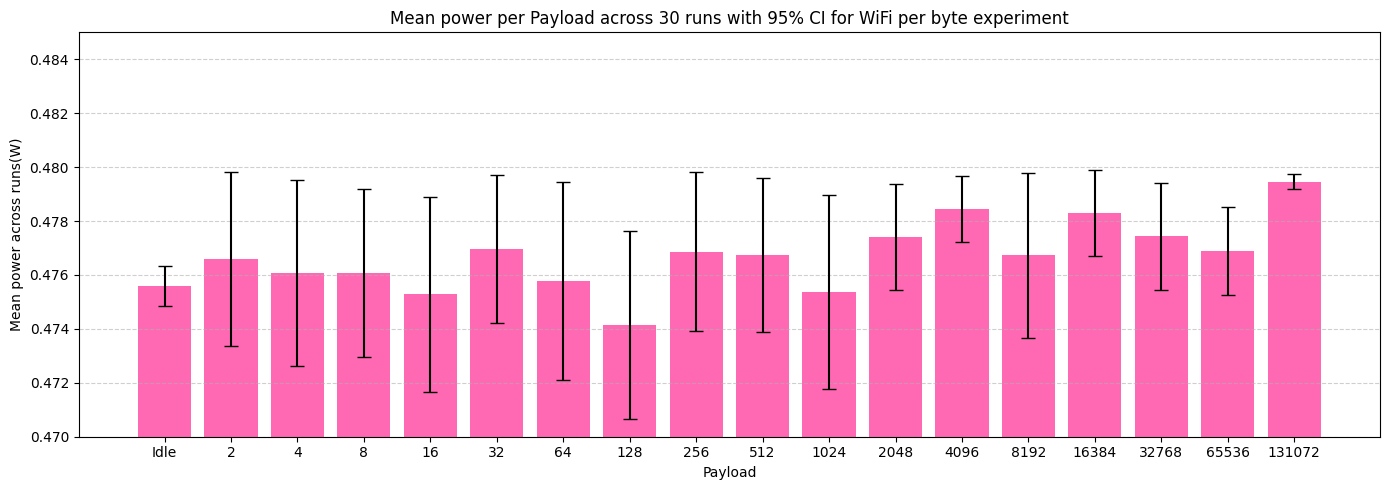

In [65]:
df = across_runs_stats.copy()

# Replace 0 with "Idle"
df["payload_label"] = df["payload_size"].astype(str)
df.loc[df["payload_size"] == 0, "payload_label"] = "Idle"

plt.figure(figsize=(14,5))

plt.bar(
    df["payload_label"],
    df["mean_power"],
    yerr=df["ci95"],
    capsize=5,
    color='hotpink'
)
#cut off y axis at 0.5
plt.ylim(0.470, 0.485)
plt.xlabel("Payload")
plt.ylabel("Mean power across runs(W)")
plt.title("Mean power per Payload across 30 runs with 95% CI for WiFi per byte experiment")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

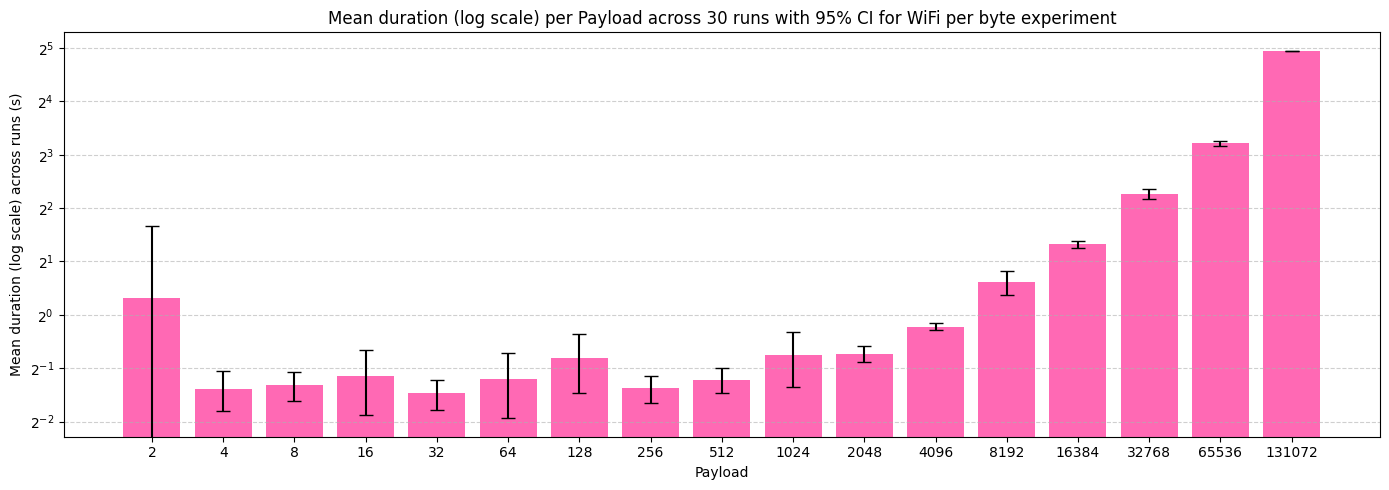

In [66]:
#exclude idle cause way l9nger and irrelevant duration
df = df[df["payload_size"] != 0]

fig, ax = plt.subplots(figsize=(14,5))

ax.bar(
    df["payload_label"],
    df["mean_duration"],
    yerr=df["ci95_duration"],
    capsize=5,
    color='hotpink'
)

#needs to be log scale to show the difference between 1 byte and 1000 bytes, otherwise the 1 byte bar is invisible
ax.set_yscale('log', base=2)

ax.set_xlabel("Payload")
ax.set_ylabel("Mean duration (log scale) across runs (s)")
ax.set_title("Mean duration (log scale) per Payload across 30 runs with 95% CI for WiFi per byte experiment")

ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Energy

in joules per run per payload

In [67]:
print(meter_df)

                     timestamp   v_shunt     phase  run  payload_size     t_s  \
0      2026-03-26 20:30:58.078  0.115073  baseline    1             0  -5.007   
1      2026-03-26 20:30:58.088  0.115073  baseline    1             0  -4.997   
2      2026-03-26 20:30:58.091  0.107809  baseline    1             0  -4.994   
3      2026-03-26 20:30:58.094  0.107809  baseline    1             0  -4.991   
4      2026-03-26 20:30:58.097  0.107809  baseline    1             0  -4.988   
...                        ...       ...       ...  ...           ...     ...   
636146 2026-03-26 21:10:56.621  0.107948      idle   30             0  32.586   
636147 2026-03-26 21:10:56.624  0.107948      idle   30             0  32.589   
636148 2026-03-26 21:10:56.628  0.107948      idle   30             0  32.593   
636149 2026-03-26 21:10:56.631  0.107948      idle   30             0  32.596   
636150 2026-03-26 21:10:56.634  0.107948      idle   30             0  32.599   

        current_A   power_W

In [68]:
def energy_with_unc(df):
    df = df.sort_values("t_s")   #make sure data is ordered by time
    # Time differences between samples (Δt)
    dt = df["t_s"].diff().fillna(0) #dt is time difference btw samples within a run and payload size group 

    # Energy: sum of P * Δt
    energy = (df["power_W"] * dt).sum()

    # Uncertainty propagation: sqrt(sum((Δt * u_P)^2))
    energy_unc = np.sqrt(((dt * df["power_unc"])**2).sum()) #we assume time uncertainty (from measurements) is negligeable

    return pd.Series({
        "energy_J": energy,
        "energy_unc": energy_unc
    })


energy_per_run = (
    meter_df[meter_df["payload_size"] != 0]   #remove idle and baseline
    .groupby(["run", "payload_size"])       
    .apply(energy_with_unc)                   #compute energy + uncertainty
    .reset_index()                            #clean dataframe
)

/var/folders/y0/ntq2pbh53yb4nxf1rt5x3bxw0000gq/T/ipykernel_41794/3046151491.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(energy_with_unc)                   #compute energy + uncertainty


In [69]:
print(energy_per_run)

     run  payload_size   energy_J  energy_unc
0      1             2   0.075280    0.000622
1      1             4   0.153944    0.000942
2      1             8   0.106021    0.000838
3      1            16   0.150286    0.000882
4      1            32   0.108806    0.000802
..   ...           ...        ...         ...
495   29         32768   2.254902    0.003530
496   29         65536   4.748418    0.005130
497   29        131072  14.845105    0.009151
498   30             1   0.008523    0.000186
499   30             2  14.271521    0.008930

[500 rows x 4 columns]


In [70]:
energy_stats = (
    energy_per_run[energy_per_run["payload_size"] != 1]
    .groupby("payload_size")
    .agg(
        mean_energy=("energy_J", "mean"),
        std_energy=("energy_J", "std"),
        count_runs=("energy_J", "count"),

        mean_energy_unc=("energy_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .assign(
        se_runs=lambda df: df["std_energy"] / np.sqrt(df["count_runs"]),
        total_unc=lambda df: np.sqrt(df["se_runs"]**2 + df["mean_energy_unc"]**2),
        ci95=lambda df: 1.96 * df["total_unc"]
    )
    .reset_index()
)
print(energy_stats)

    payload_size  mean_energy  std_energy  count_runs  mean_energy_unc  \
0              2     0.588706    2.585870          30         0.000331   
1              4     0.180173    0.119263          29         0.000185   
2              8     0.190266    0.093511          29         0.000190   
3             16     0.210469    0.216249          29         0.000200   
4             32     0.170409    0.084766          29         0.000181   
5             64     0.201944    0.206585          29         0.000198   
6            128     0.270503    0.274332          29         0.000228   
7            256     0.183284    0.083302          29         0.000187   
8            512     0.204425    0.082546          29         0.000197   
9           1024     0.278536    0.244228          29         0.000229   
10          2048     0.286218    0.077686          29         0.000235   
11          4096     0.409855    0.051960          29         0.000281   
12          8192     0.727631    0.281

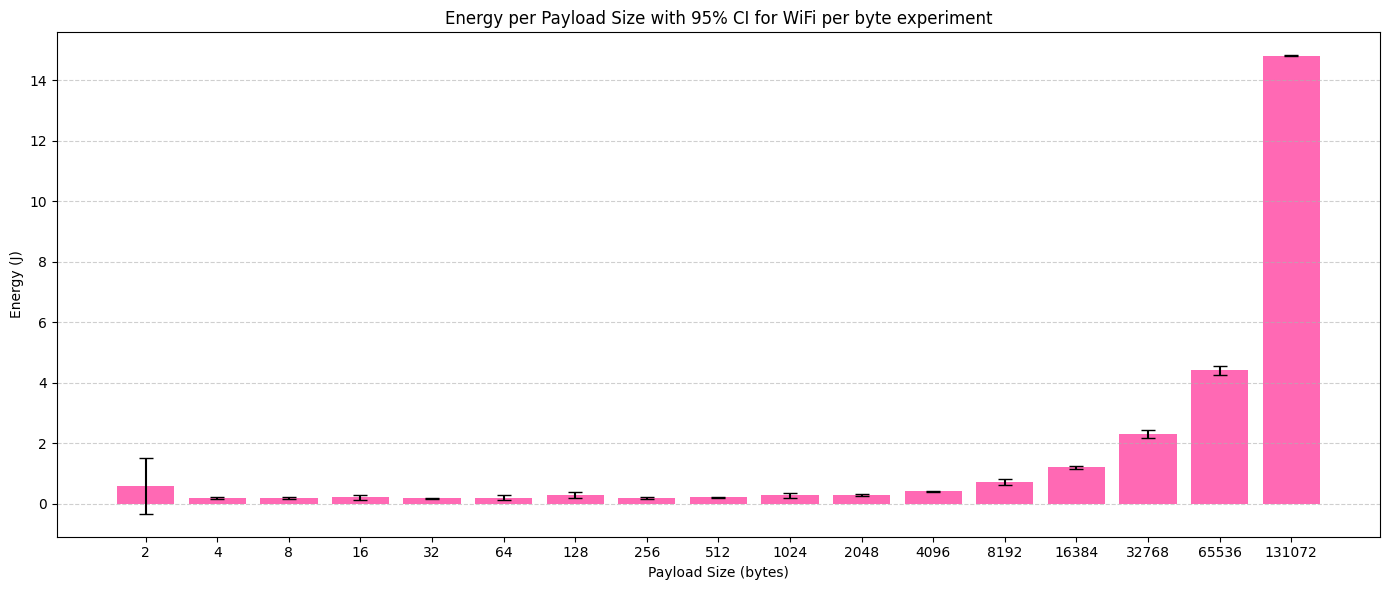

In [71]:
plt.figure(figsize=(14, 6))
plt.bar(
    energy_stats["payload_size"].astype(str),
    energy_stats["mean_energy"],
    yerr=energy_stats["ci95"],
    capsize=5,
    color='hotpink'
)
plt.xlabel("Payload Size (bytes)")
plt.ylabel("Energy (J)")
plt.title("Energy per Payload Size with 95% CI for WiFi per byte experiment")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [72]:
print(energy_stats[["payload_size", "mean_energy"]])

    payload_size  mean_energy
0              2     0.588706
1              4     0.180173
2              8     0.190266
3             16     0.210469
4             32     0.170409
5             64     0.201944
6            128     0.270503
7            256     0.183284
8            512     0.204425
9           1024     0.278536
10          2048     0.286218
11          4096     0.409855
12          8192     0.727631
13         16384     1.195872
14         32768     2.288428
15         65536     4.414364
16        131072    14.816892


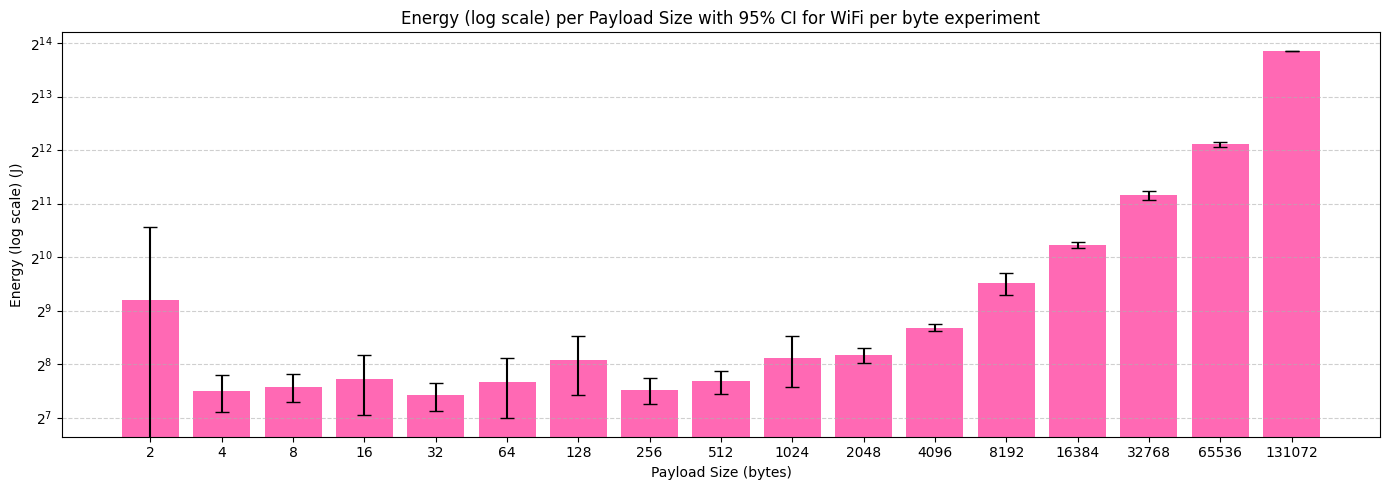

In [39]:
fig, ax = plt.subplots(figsize=(14,5))
ax.bar(
    energy_stats["payload_size"].astype(str),
    energy_stats["mean_energy"],
    yerr=energy_stats["ci95"],
    capsize=5,
    color='hotpink'
)
#gotta log scale it
ax.set_yscale('log', base=2)

ax.set_xlabel("Payload Size (bytes)")
ax.set_ylabel("Energy (log scale) (J)")
ax.set_title("Energy (log scale) per Payload Size with 95% CI for WiFi per byte experiment")
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Old stats without power

## Stats about voltage
nothing about power yet cause i dont know shunt resistance

In [73]:
voltage_df = voltage_df[voltage_df["payload_size"] != 1]
summary_V_shunt = (
    voltage_df
    .groupby("payload_size")["v_shunt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary_V_shunt["sem"] = summary_V_shunt["std"] / np.sqrt(summary_V_shunt["count"])  # standard error
summary_V_shunt["ci95"] = 1.96 * summary_V_shunt["sem"]  # 95% confidence interval

print(summary_V_shunt)

    payload_size      mean       std   count       sem      ci95
0              0  0.107570  0.002740  189905  0.000006  0.000012
1              2  0.107045  0.003700   10250  0.000037  0.000072
2              4  0.106137  0.004294    3091  0.000077  0.000151
3              8  0.106608  0.004022    3236  0.000071  0.000139
4             16  0.105236  0.004901    3629  0.000081  0.000159
5             32  0.106938  0.003573    2876  0.000067  0.000131
6             64  0.105188  0.005073    3440  0.000087  0.000170
7            128  0.106568  0.004651    4612  0.000068  0.000134
8            256  0.106957  0.003615    3122  0.000065  0.000127
9            512  0.106935  0.003567    3454  0.000061  0.000119
10          1024  0.105446  0.004819    4810  0.000069  0.000136
11          2048  0.107485  0.002558    4842  0.000037  0.000072
12          4096  0.107959  0.001737    6871  0.000021  0.000041
13          8192  0.106841  0.003868   12344  0.000035  0.000068
14         16384  0.10786

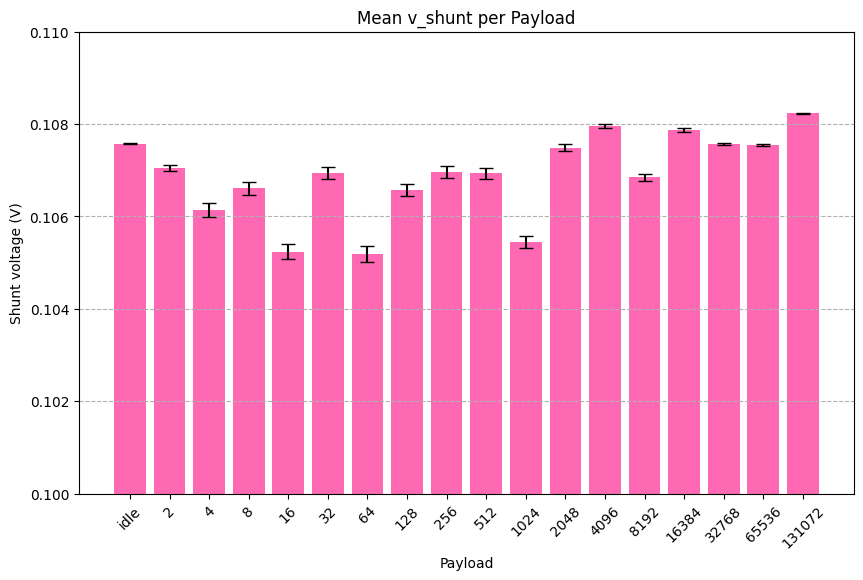

In [75]:
summary_V_shunt["payload_label"] = summary_V_shunt["payload_size"].astype(str)
summary_V_shunt.loc[summary_V_shunt["payload_size"] == 0, "payload_label"] = "idle"

plt.figure(figsize=(10, 6))
plt.bar(
    summary_V_shunt["payload_label"],
    summary_V_shunt["mean"],
    yerr=summary_V_shunt["ci95"],
    capsize=5,
    color='hotpink',
)

#cut off y axis at 0.1
plt.ylim(0.10, 0.11)
plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

same thing but different, i kinda hate this

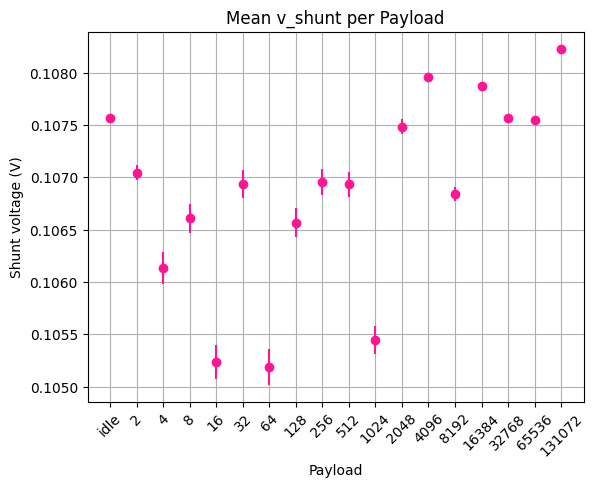

In [76]:
plt.errorbar(
    summary_V_shunt["payload_label"],
    summary_V_shunt["mean"],
    yerr=summary_V_shunt["ci95"],
    fmt='o',
    color= 'deeppink'
)

plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid()
plt.show()

wanna see outliers and stuff

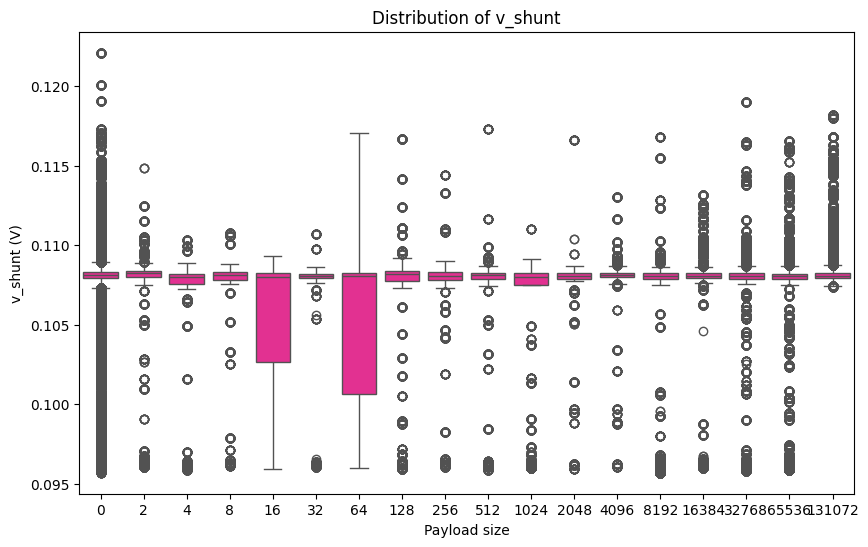

In [77]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=voltage_df,
    x="payload_size",
    y="v_shunt",
    color='deeppink' #why is the color not changing?
)

plt.xlabel("Payload size")
plt.ylabel("v_shunt (V)")
plt.title("Distribution of v_shunt")
plt.show()

## Stats about time

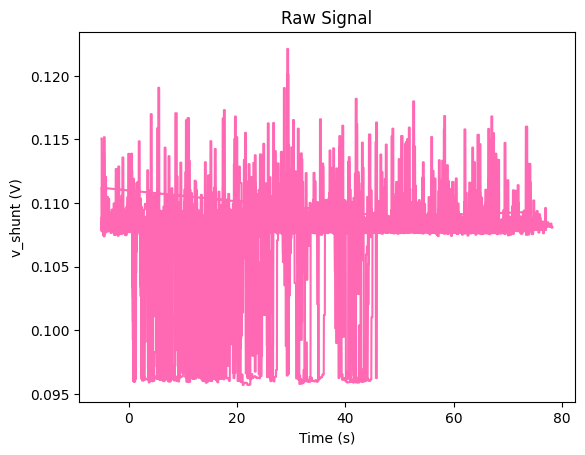

In [81]:
plt.plot(voltage_df["t_s"], voltage_df["v_shunt"], color='hotpink')
plt.xlabel("Time (s)")
plt.ylabel("v_shunt (V)")
plt.title("Raw Signal")
plt.show()

In [82]:
events_df["duration_s"] = (
    events_df["t_end_s"] - events_df["t_start_s"]
)

tx_summary = (
    events_df
    .groupby("payload_size")["duration_s"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
tx_summary["sem"] = tx_summary["std"] / np.sqrt(tx_summary["count"])  # standard error
tx_summary["ci95"] = 1.96 * tx_summary["sem"]  #95% confidence interval
print(tx_summary)

KeyError: 't_end_s'

In [ ]:
tx_summary["payload_size"] = tx_summary["payload_size"].astype(str)
#please order omg
plt.figure()
plt.bar(
    tx_summary["payload_size"].astype(str),
    tx_summary["mean"],
    yerr=tx_summary["ci95"],
    color='hotpink'
)
plt.loc = sorted(events_df["payload_size"].unique())
plt.xlabel("Payload size")
plt.ylabel("TX duration (s)")
plt.title("Transmission Time vs Payload Size")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

NameError: name 'tx_summary' is not defined